In [51]:
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd

import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

import warnings
warnings.filterwarnings('ignore')

In [52]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite')

In [53]:
yys, yye= 2002, 2023
# lon_min, lon_max, lat_min, lat_max, area = 11, 12.5, 45, 46, 'PADOVA'
# lon_min, lon_max, lat_min, lat_max, area = 10.5, 13.5, 44.5, 47, 'VENETO'
lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [54]:
# DATA = xr.open_dataset(os.path.join(dir_base,'IMERG','3h','IMERG_Italy_3h_2001_01_01_2023_12_31.nc'))
DATA = xr.open_dataset(os.path.join(dir_base,'CMORPH','3h','CMORPH_Italy_3hr_1998_01_01_2023_12_31.nc'))


DATA = DATA.sel(time=DATA.time.dt.year.isin(np.arange(yys,yye+1)))

PRE_data = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))

lats = PRE_data['lat'].data
lons = PRE_data['lon'].data

lon2d, lat2d = np.meshgrid(lons, lats)

nlon = np.size(lons)
nlat = np.size(lats)
ntime = len(PRE_data['time'])

year_vector = np.unique(pd.to_datetime(PRE_data['time']).year)

PRE_data = PRE_data.where(PRE_data >= 0) 

In [55]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.unary_union # ONLY FOR VENETO

In [56]:
print(f'Extracting lat and lon points for {area} area')
print()
PRE_study = PRE_data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

lat_ref = PRE_study.lat.values
lon_ref = PRE_study.lon.values

lon2d, lat2d = np.meshgrid(lon_ref, lat_ref)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)

ndices_lat, ndices_lon = np.where(mask_study)

lon_T, lat_T = np.meshgrid(lon_ref[ndices_lon], lat_ref[ndices_lat])

del PRE_study

Extracting lat and lon points for ITALY area



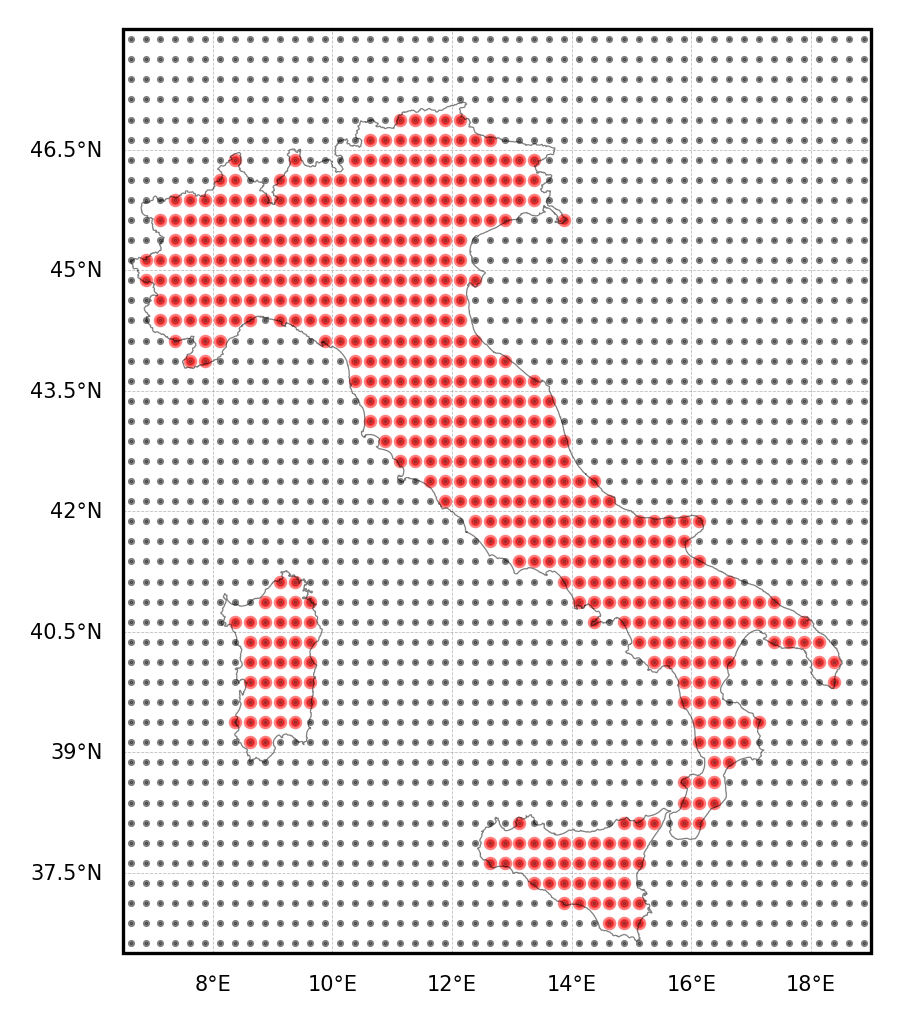

In [58]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(4,4),dpi=300)
gs = gridspec.GridSpec(1,1)

ax = fig.add_subplot(gs[0, 0], projection=proj)
GEOMETRY.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.3, zorder=21, alpha=0.5)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
# ax.coastlines(linewidth=0.1)

ax.scatter(lon2d, lat2d, s=0.5, color='k', alpha=0.5, transform=proj, zorder=20)
ax.scatter(lon_ref[ndices_lon], lat_ref[ndices_lat], s=5, color='red', alpha=0.5, transform=proj, zorder=20)

gl = ax.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.right_labels = False
gl.left_labels = True
gl.xlabel_style = {'size': 5, 'color': 'k'}
gl.ylabel_style = {'size': 5, 'color': 'k'}